# **Error Bars & Confidence Intervals in Plots**

# 1. Import Libraries & Dataset

In [19]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# Load dataset
df = pd.read_csv("../datasets/ecommerce_sales.csv", parse_dates = ["order_date"])

# 2. Error Bars

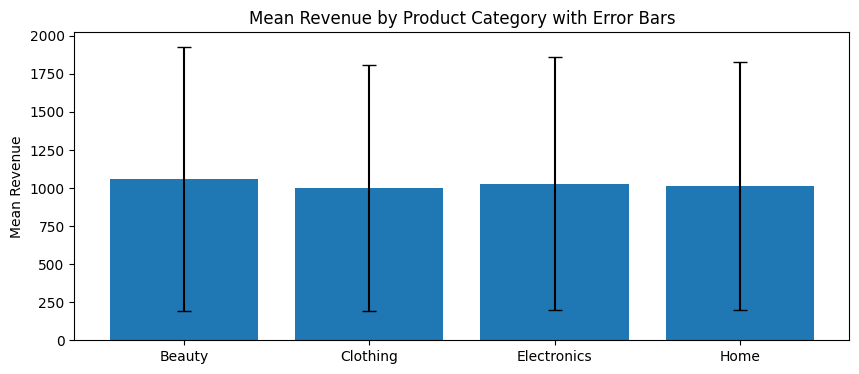

In [21]:
# Mean Revenue by Product Category
stats = df.groupby("product_category")["revenue"].agg(["mean", "std"])

# plot
fig, ax = plt.subplots(figsize = (10, 4))
ax.bar(stats.index, stats["mean"], yerr = stats["std"], capsize = 5)

ax.set_title("Mean Revenue by Product Category with Error Bars")
ax.set_ylabel("Mean Revenue")
plt.show()

# 3. Confidence Bands

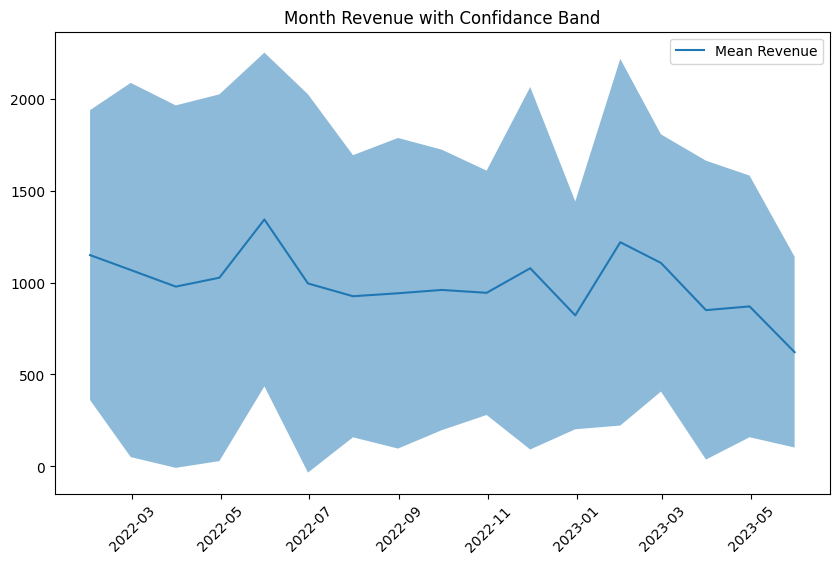

In [28]:
# select 500 rows
df = df.head(n = 500)

# confidence bands - monthly revenue trend with variability
monthly_revenue = (df.set_index("order_date")["revenue"].resample("ME").agg(["mean", "std"]))

# plot
fig, ax = plt.subplots(figsize = (10, 6))
ax.plot(monthly_revenue.index, monthly_revenue["mean"], label = "Mean Revenue")
ax.fill_between(monthly_revenue.index, 
                monthly_revenue["mean"] - monthly_revenue["std"],
                monthly_revenue["mean"] + monthly_revenue["std"],
                alpha = 0.5)

ax.tick_params(axis = "x", rotation = 45)
ax.set_title("Month Revenue with Confidance Band")
ax.legend()

plt.show()